In [1]:
import pandas as pd

# Cargar precios ajustados
adj_close = pd.read_csv(
    "../Datos_csv/adj_close.csv",
    index_col=0,
    parse_dates=True
)

# Cargar volumen
volume = pd.read_csv(
    "../Datos_csv/volume.csv",
    index_col=0,
    parse_dates=True
)


In [2]:
print(volume.shape)
print(adj_close.shape)


(1276, 63)
(1276, 63)


Yahoo Finance proporciona precios de apertura (Open), máximo (High), mínimo (Low) y cierre (Close), el precio ajustado por dividendos y splits (Adj Close), que se utiliza para calcular retornos, y el volumen negociado (Volume), que sirve como medida de liquidez.


In [3]:

# Nulos por ticker (para saber si tienen dias sin datos dentro de cada etf)
nan_ratio = adj_close.isna().mean().sort_values(ascending=False)
display(nan_ratio.head(15))

# Tickers que han bajado bien (pocos NaNs)
good = nan_ratio[nan_ratio <= 0.05].index.tolist()
print("Tickers con <=5% NaNs:", len(good))


AGG    0.0
BIL    0.0
BND    0.0
DBC    0.0
DIA    0.0
DVY    0.0
EEM    0.0
EFA    0.0
EWG    0.0
EWJ    0.0
EWQ    0.0
EWT    0.0
EWU    0.0
EWY    0.0
EWZ    0.0
dtype: float64

Tickers con <=5% NaNs: 63


El objetivo de este proyecto es analizar si predicciones aproximadas de ganancias y riesgo diario pueden ayudar a decidir mejor cómo gestionar una cartera de inversión, teniendo en cuenta los costes de compra y venta y la posibilidad de mantener la cartera sin cambios.

Para que la cartera sea realista, se analiza la liquidez de los ETFs mediante el volumen diario negociado en dólares, ya que indica cuánto dinero real se mueve cada día en el mercado. Se eliminan los ETFs con poco volumen porque son más difíciles y caros de comprar o vender. Para ello, se fija un volumen mínimo diario como umbral, que permite trabajar solo con activos suficientemente líquidos.

In [4]:
# Dollar Volume diario = precio ajustado × volumen
dollar_vol = adj_close * volume
dollar_vol.head()

,AGG,BIL,BND,DBC,DIA,DVY,EEM,EFA,EWG,EWJ,...,XLB,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,6.526617e+08,1.245880e+08,5.723817e+08,7.302093e+07,1.412709e+09,9.106205e+07,2.230334e+09,1.676608e+09,1.360359e+08,5.450072e+08,...,5.928555e+08,1.063968e+09,1.255895e+09,1.296816e+09,1.292587e+09,7.601383e+08,1.485269e+08,6.629046e+08,1.346421e+09,1.387397e+09
2021-01-05,7.601341e+08,7.376403e+07,4.871727e+08,3.133269e+07,9.328616e+08,1.008118e+08,2.528291e+09,1.252785e+09,1.499872e+08,3.437265e+08,...,8.897718e+08,1.567241e+09,9.448108e+08,1.293721e+09,7.651767e+08,6.360657e+08,1.323910e+08,4.373039e+08,1.163991e+09,4.830628e+08
2021-01-06,1.081019e+09,1.342224e+08,4.460014e+08,4.414257e+07,2.056109e+09,1.010979e+08,2.650726e+09,1.631507e+09,1.404826e+08,4.751371e+08,...,1.676104e+09,1.459247e+09,2.860543e+09,1.613892e+09,1.658186e+09,8.317867e+08,2.194734e+08,9.670478e+08,1.898854e+09,6.882305e+08
2021-01-07,6.708938e+08,9.802280e+07,4.647668e+08,3.456472e+07,1.167174e+09,6.258733e+07,1.946034e+09,1.206536e+09,1.641557e+08,5.045221e+08,...,6.465379e+08,8.832445e+08,1.825930e+09,8.417121e+08,1.227713e+09,8.151047e+08,1.023868e+08,6.570712e+08,1.338235e+09,5.342003e+08
2021-01-08,7.403677e+08,1.386635e+08,5.762053e+08,3.872581e+07,9.207275e+08,5.937198e+07,3.701067e+09,1.638457e+09,1.391429e+08,5.868897e+08,...,5.883787e+08,1.075679e+09,1.538987e+09,9.167183e+08,7.788904e+08,1.053640e+09,1.030737e+08,7.207210e+08,1.013394e+09,7.525971e+08


In [5]:
median_dollar_vol = dollar_vol.median()
liquidity_table = median_dollar_vol.sort_values(ascending=False)
display(liquidity_table) #ver de más 


SPY     3.255314e+10
QQQ     1.777073e+10
IWM     5.671854e+09
TLT     2.431828e+09
HYG     2.310176e+09
            ...     
EWU     6.066684e+07
DVY     5.972024e+07
VLUE    4.700017e+07
DBC     2.785626e+07
EWQ     1.591684e+07
Length: 63, dtype: float64

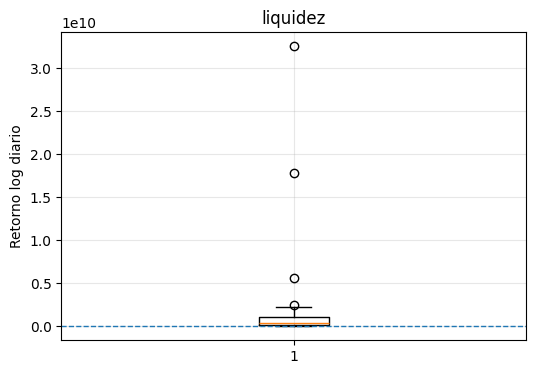

In [6]:
import matplotlib.pyplot as plt

etf = "SPY"   # cambia por el que quieras (SPY, QQQ, USO, etc.)

plt.figure(figsize=(6, 4))

plt.boxplot(liquidity_table.dropna(), vert=True)
plt.axhline(0, linestyle="--", linewidth=1)

plt.title(f"liquidez")
plt.ylabel("Retorno log diario")

plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# --- Umbral de liquidez ---
threshold = 10_000_000  # 10M USD
valid_tickers = median_dollar_vol[median_dollar_vol >= threshold].index

print("ETFs antes del filtro:", len(median_dollar_vol))
print("ETFs después del filtro:", len(valid_tickers))

# --- Filtrar cada dataset  ---
adj_close_f = adj_close.loc[:, valid_tickers].copy()
volume_f    = volume.loc[:, valid_tickers].copy()

#  también filtra dollar_vol
dollar_vol_f = dollar_vol.loc[:, valid_tickers].copy()

ETFs antes del filtro: 63
ETFs después del filtro: 63


Todos los ETFs considerados presentan un volumen diario negociado en dólares superior al umbral mínimo establecido, por lo que no fue necesario excluir ninguno por motivos de liquidez.

CALCULAMOS LOS RETORNOS SIMPLES

(hoy − ayer) / ayer


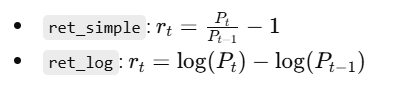

In [11]:
import numpy as np
# Retornos
ret_simple = adj_close_f.pct_change()
ret_log = np.log(adj_close_f).diff() #diferencia con el dia anterior


In [12]:

# Estadísticas descriptivas de los retornos
stats = pd.DataFrame({
    "Retorno medio diario": ret_log.mean(),
    "Desviación típica diaria": ret_log.std(),
    "Retorno mínimo observado": ret_log.min(),
    "Percentil 5%": ret_log.quantile(0.05), #Solo el 5% de los días fueron peores que este valor,los percentiles describen lo que pasa normalmente
    "Percentil 25%": ret_log.quantile(0.25),
    "Mediana": ret_log.quantile(0.50),
    "Percentil 75%": ret_log.quantile(0.75),
    "Percentil 95%": ret_log.quantile(0.95),
    "Retorno máximo observado": ret_log.max()
})

# Ordenar por riesgo (volatilidad)
stats = stats.sort_values("Desviación típica diaria", ascending=False)

# Mostrar TODOS los ETFs
display(stats)


,Retorno medio diario,Desviación típica diaria,Retorno mínimo observado,Percentil 5%,Percentil 25%,Mediana,Percentil 75%,Percentil 95%,Retorno máximo observado
SLV,0.000824,0.021201,-0.336037,-0.027873,-0.009590,0.000462,0.011420,0.032051,0.087487
USO,0.000662,0.021036,-0.123962,-0.033490,-0.011637,0.001509,0.013694,0.032124,0.076115
FXI,-0.000042,0.019867,-0.105268,-0.029030,-0.011263,-0.000725,0.010424,0.030209,0.192612
MCHI,-0.000132,0.019373,-0.114395,-0.028250,-0.010620,-0.000662,0.009846,0.030597,0.190103
EWZ,0.000329,0.017723,-0.077276,-0.029867,-0.009296,0.000973,0.011436,0.028281,0.093990
...,...,...,...,...,...,...,...,...,...
TIP,0.000035,0.003941,-0.016982,-0.006396,-0.002078,0.000092,0.002259,0.005759,0.017516
AGG,-0.000016,0.003798,-0.016529,-0.006085,-0.002254,0.000000,0.002203,0.006009,0.021243
BND,-0.000018,0.003760,-0.016284,-0.006109,-0.002221,0.000000,0.002222,0.006029,0.020491
SHY,0.000062,0.001222,-0.005101,-0.001844,-0.000494,0.000000,0.000605,0.001976,0.009924


Histograma de retornos diarios

Eje horizontal (X)


→ valor del retorno diario:
0 = no cambia; negativo = pierde; positivo = gana


Eje vertical (Y)

→ cuántas veces pasó eso: barras altas = pasó muchas veces;
barras bajas = pasó pocas veces

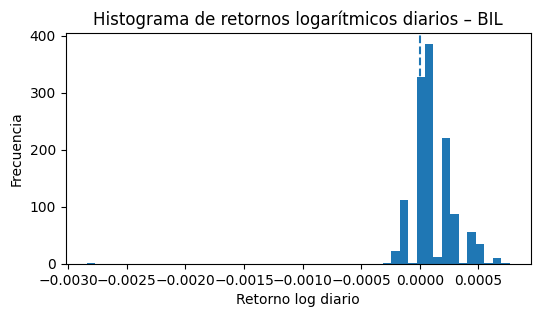

In [27]:
import matplotlib.pyplot as plt

etf = "BIL"   # ETF a analizar

plt.figure(figsize=(6, 3))
plt.hist(ret_log[etf], bins=50)
plt.title(f"Histograma de retornos logarítmicos diarios – {etf}")
plt.xlabel("Retorno log diario")
plt.ylabel("Frecuencia")
plt.axvline(0, linestyle="--")  # línea en 0 para referencia
plt.show()


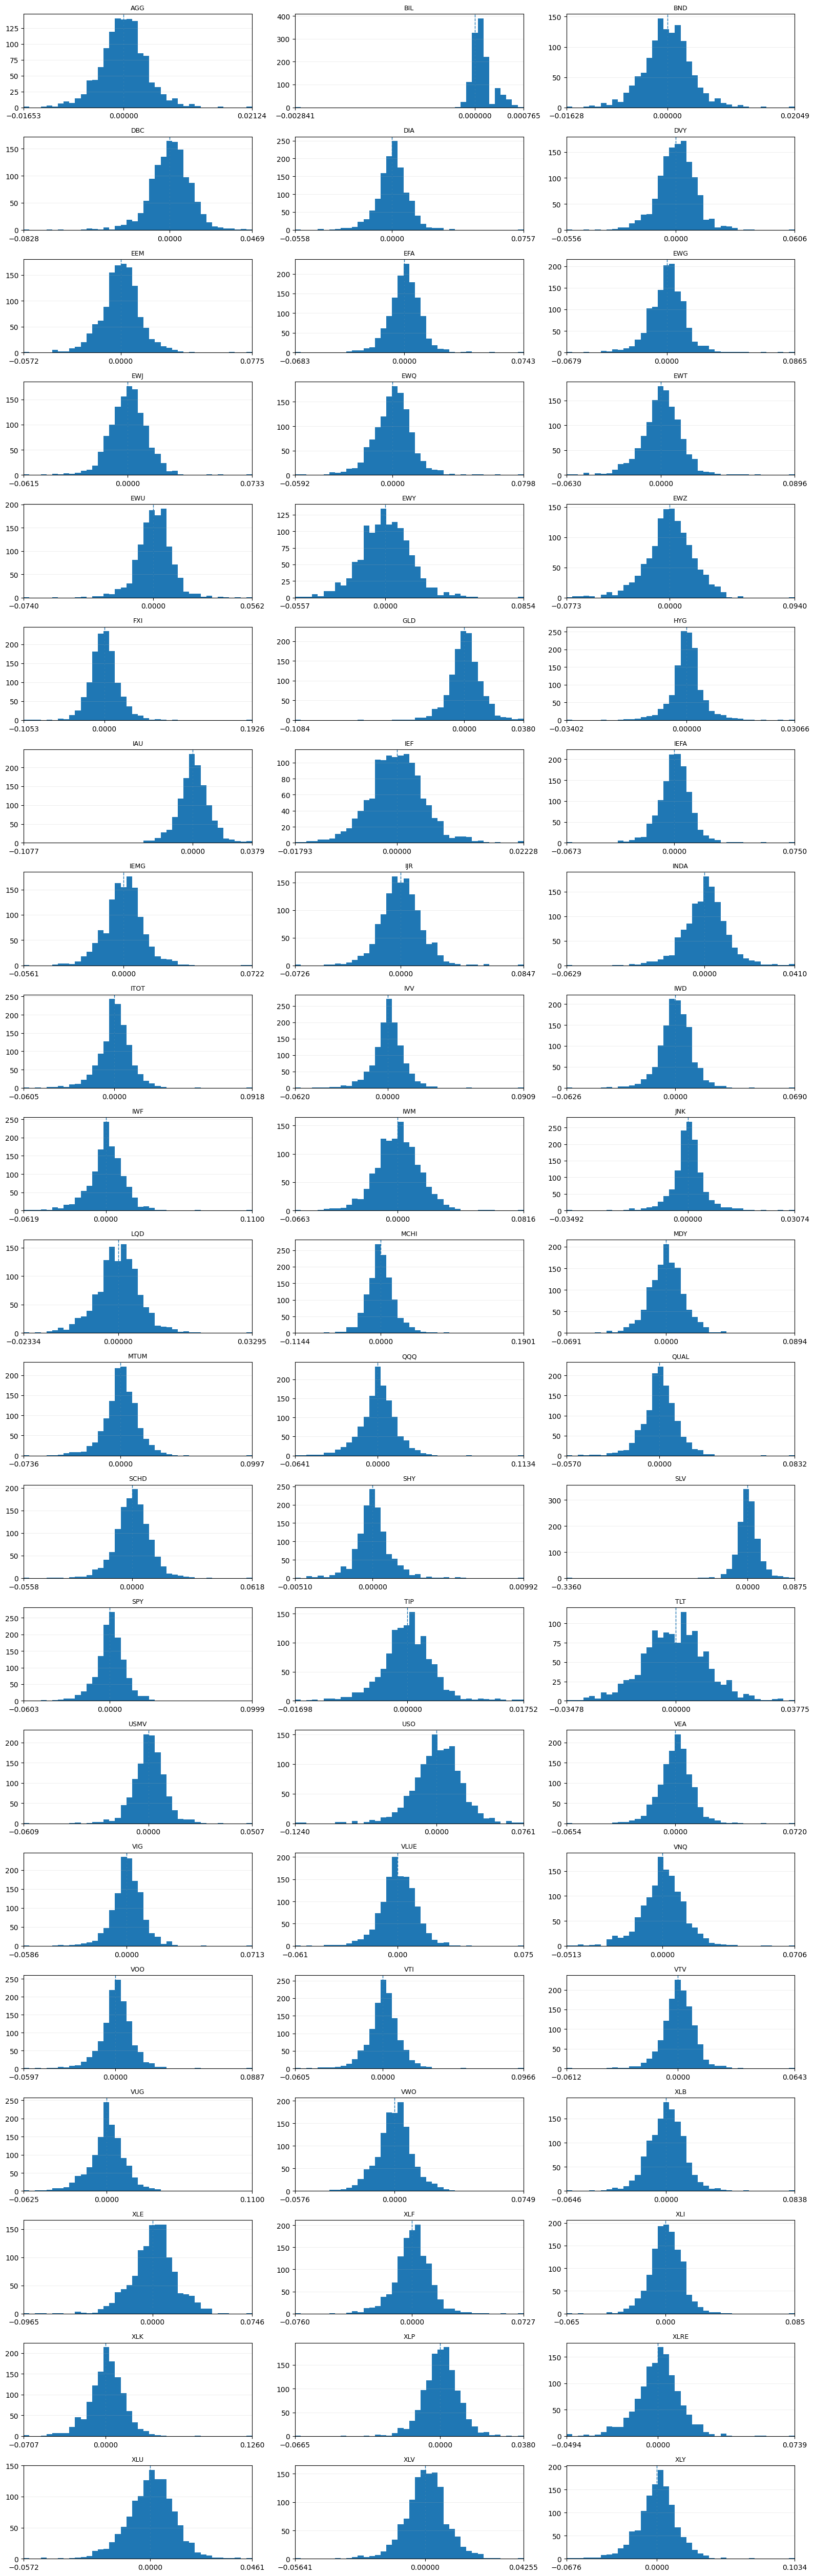

In [14]:
import matplotlib.pyplot as plt
import math
import numpy as np

n_cols = 3
bins = 40

n_etfs = len(ret_log.columns)
n_rows = math.ceil(n_etfs / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 2.4 * n_rows))
axes = axes.flatten()

for i, etf in enumerate(ret_log.columns):
    x = ret_log[etf].dropna().values

    # rango completo real
    x_min = x.min()
    x_max = x.max()

    # seguridad por si el rango es casi cero (BIL, SHY)
    if np.isclose(x_min, x_max):
        eps = max(abs(x_min), 1e-6)
        x_min -= eps
        x_max += eps

    axes[i].hist(x, bins=bins)
    axes[i].axvline(0, linestyle="--", linewidth=1)

    axes[i].set_title(etf, fontsize=9)
    axes[i].grid(True, alpha=0.2)
    axes[i].set_xlim(x_min, x_max)

    # marcar el 0 si entra
    if x_min < 0 < x_max:
        axes[i].set_xticks([x_min, 0, x_max])
    else:
        axes[i].set_xticks([x_min, x_max])

# borrar ejes vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.tight_layout()
plt.show()


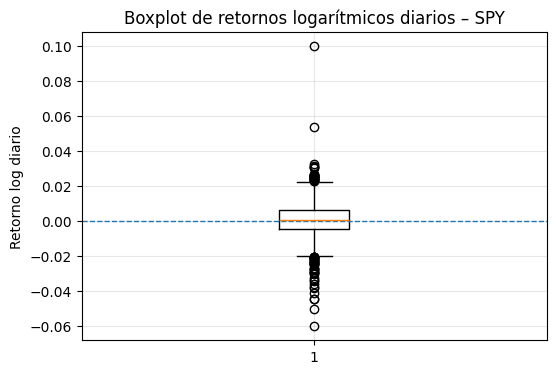

In [15]:
import matplotlib.pyplot as plt

etf = "SPY"   # cambia por el que quieras (SPY, QQQ, USO, etc.)

plt.figure(figsize=(6, 4))

plt.boxplot(ret_log[etf].dropna(), vert=True)
plt.axhline(0, linestyle="--", linewidth=1)

plt.title(f"Boxplot de retornos logarítmicos diarios – {etf}")
plt.ylabel("Retorno log diario")

plt.grid(True, alpha=0.3)
plt.show()


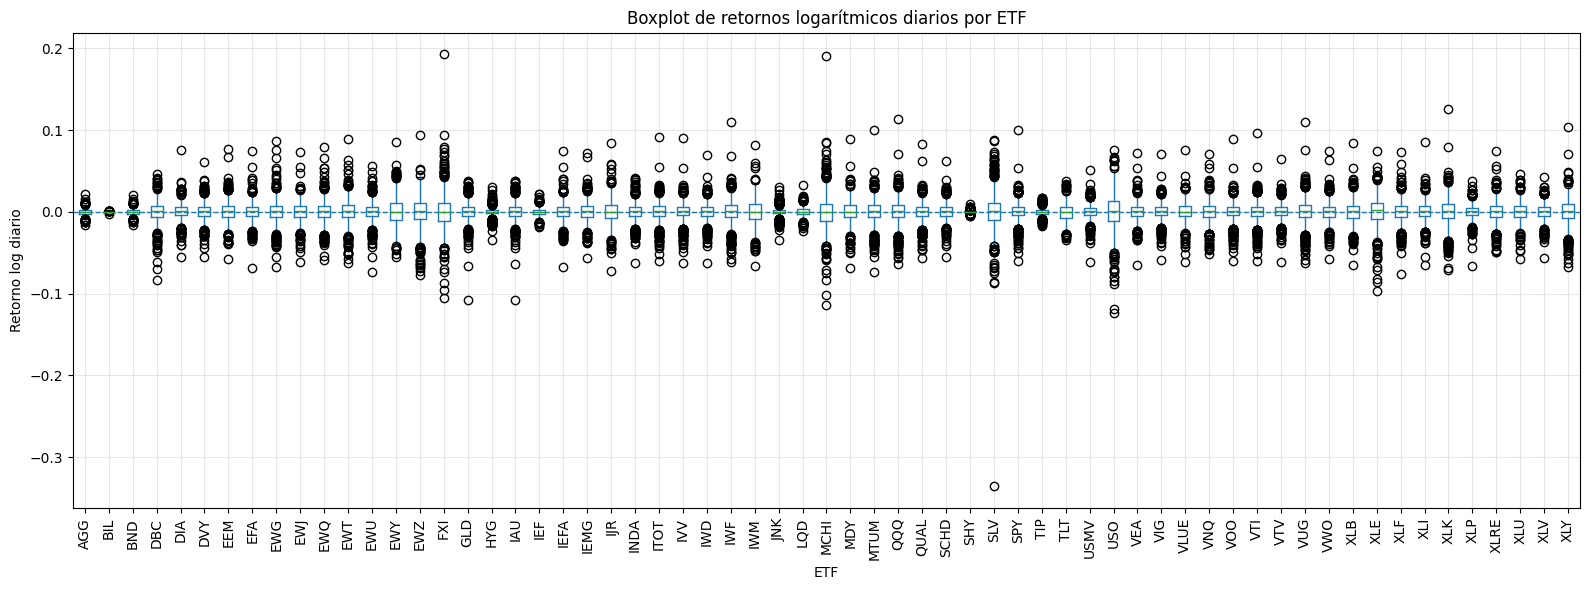

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 6))

ret_log.boxplot(rot=90)
plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Boxplot de retornos logarítmicos diarios por ETF")
plt.ylabel("Retorno log diario")
plt.xlabel("ETF")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


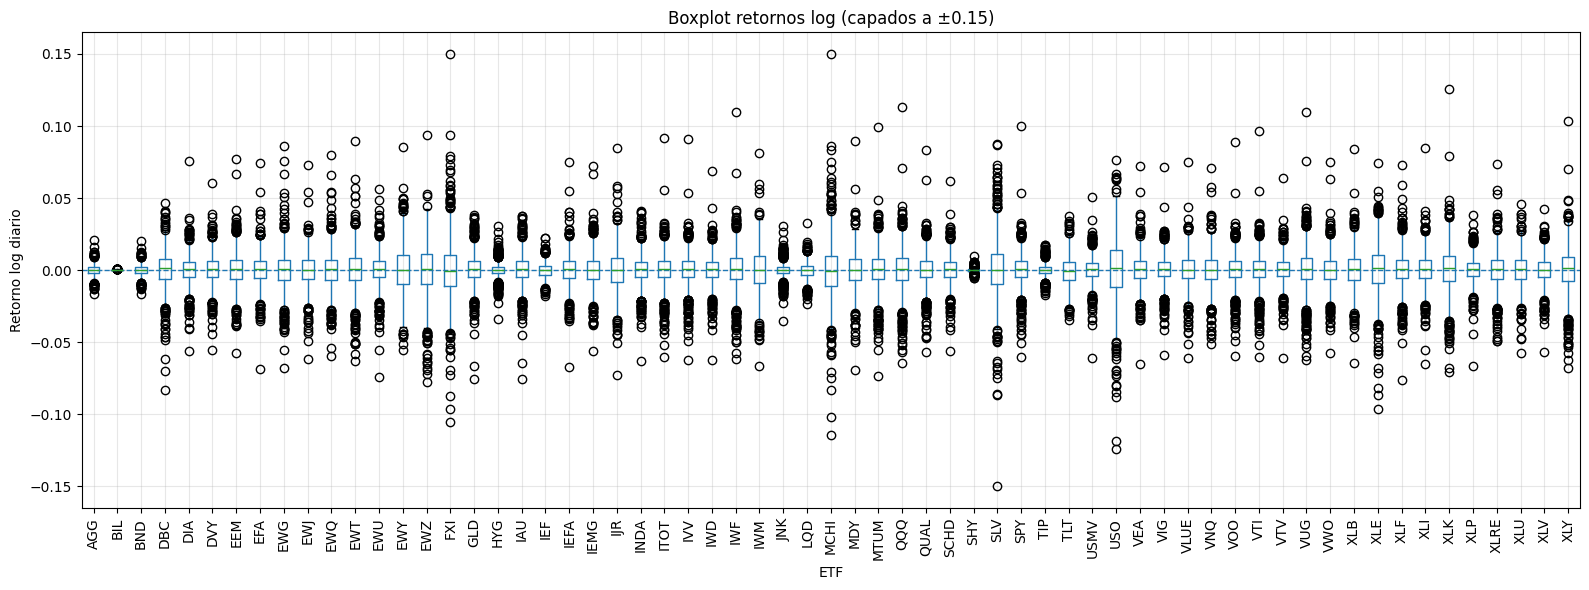

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# Umbral
thr = 0.15 #investigar un criterio, igual no nos interesa quitarlo proq nos interesa ver el cambio de volatilidades

# Capar extremos (winsorizar)
returns = returns.clip(lower=-thr, upper=thr)

# Boxplot igual que antes
plt.figure(figsize=(16, 6))
returns.boxplot(rot=90)
plt.axhline(0, linestyle="--", linewidth=1)

plt.title(f"Boxplot retornos log (capados a ±{thr})")
plt.ylabel("Retorno log diario")
plt.xlabel("ETF")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


ANÁLISIS DE COVARIANZAS

Covarianza positiva → se mueven juntos

Covarianza negativa → uno sube cuando otro baja

Covarianza ≈ 0 → no hay relación clara

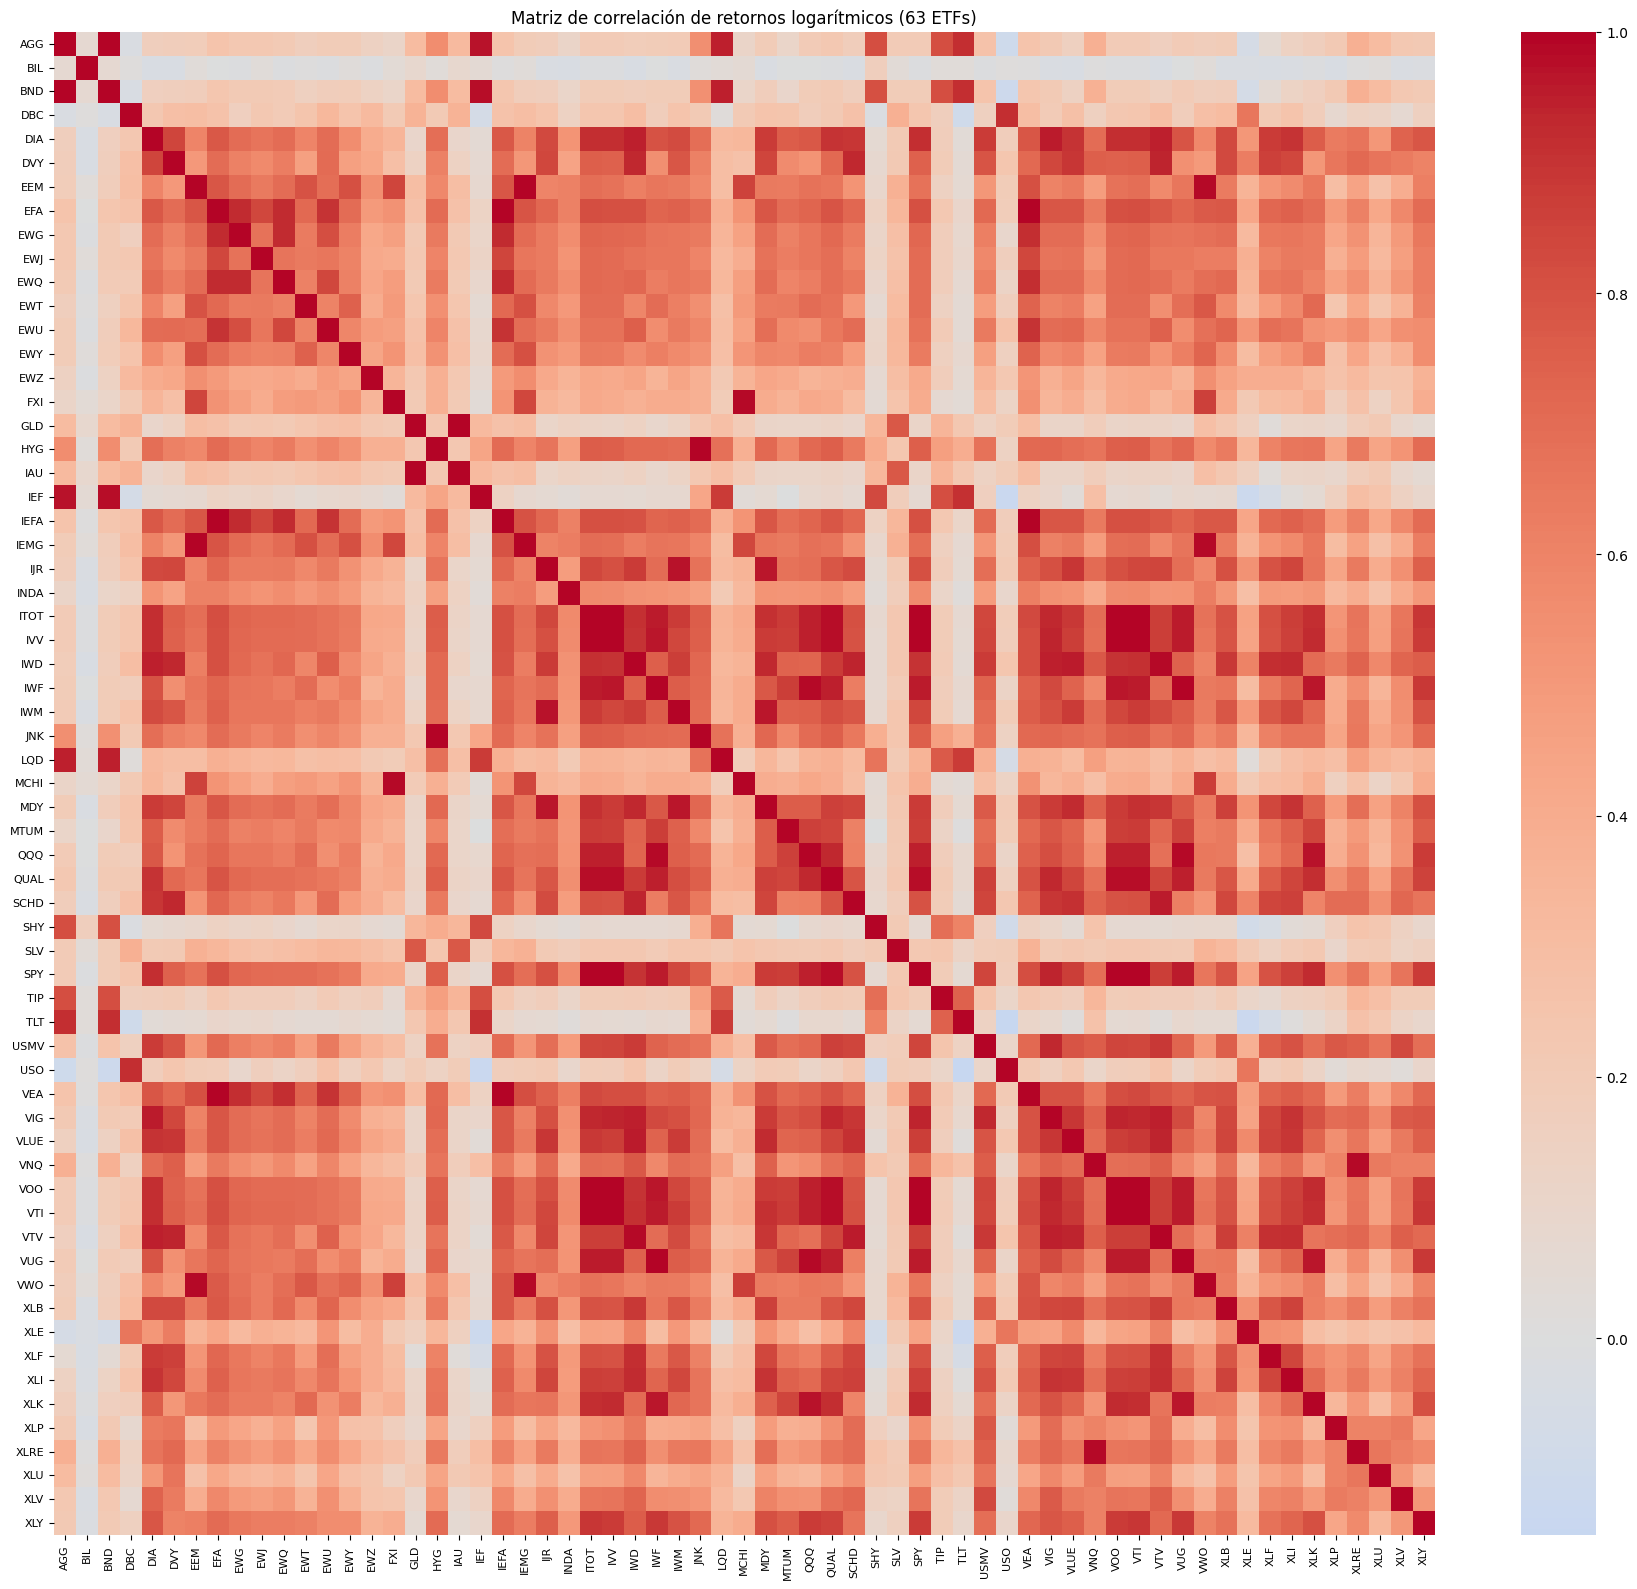

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = ret_log.corr()

plt.figure(figsize=(18, 16))
ax = sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    xticklabels=corr.columns,
    yticklabels=corr.columns
)

# Rotar etiquetas
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)

plt.title("Matriz de correlación de retornos logarítmicos (63 ETFs)")
plt.tight_layout()
plt.show()


In [18]:
import pandas as pd
import numpy as np
import networkx as nx

# Matriz de correlaciones

# Umbral
threshold = 0.95

# Crear grafo, ETFs (nodos) y correlación alta (conexión)
G = nx.Graph()

# Añadir nodos
for etf in corr.columns:
    G.add_node(etf)

print("numero de nodos:", G.number_of_nodes())


# Añadir aristas para correlaciones altas
for i in corr.columns:
    for j in corr.columns:
        if i != j and abs(corr.loc[i, j]) >= threshold:
            G.add_edge(i, j)



numero de nodos: 63


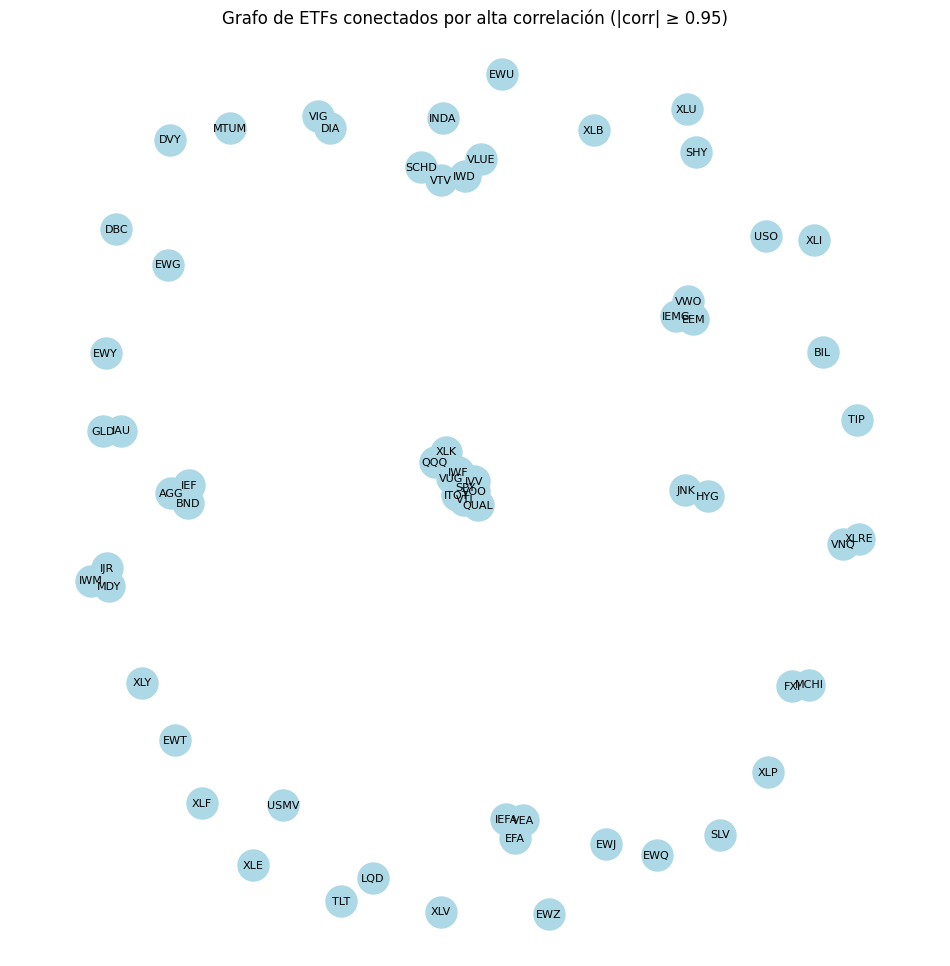

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 12))

# Posición "natural" de los nodos
pos = nx.spring_layout(G, seed=42)

# Dibujar nodos
nx.draw_networkx_nodes(
    G, pos,
    node_size=500,
    node_color="lightblue"
)

# Dibujar aristas (conexiones)
nx.draw_networkx_edges(
    G, pos,
    alpha=0.5
)

# Dibujar etiquetas
nx.draw_networkx_labels(
    G, pos,
    font_size=8
)

plt.title("Grafo de ETFs conectados por alta correlación (|corr| ≥ 0.95)")
plt.axis("off")
plt.show()


El uso de grafos permite identificar grupos de ETFs altamente correlacionados, capturando relaciones directas e indirectas que no se observan al analizar pares de activos de forma aislada.

In [20]:
# Componentes conexos = grupos
groups = list(nx.connected_components(G))

# Convertir a DataFrame para verlos bien
groups_df = pd.DataFrame({
    "Grupo": range(1, len(groups) + 1),
    "ETFs": [sorted(list(g)) for g in groups],
    "Tamaño": [len(g) for g in groups]
})

# Ordenar por tamaño (grupos más grandes primero)
groups_df = groups_df.sort_values("Tamaño", ascending=False)

groups_df


,Grupo,ETFs,Tamaño
19,20,"[ITOT, IVV, IWF, QQQ, QUAL, SPY, VOO, VTI, VUG...",10
20,21,"[IWD, SCHD, VLUE, VTV]",4
17,18,"[IJR, IWM, MDY]",3
6,7,"[EFA, IEFA, VEA]",3
0,1,"[AGG, BND, IEF]",3
5,6,"[EEM, IEMG, VWO]",3
14,15,"[FXI, MCHI]",2
16,17,"[HYG, JNK]",2
15,16,"[GLD, IAU]",2
3,4,"[DIA, VIG]",2


elegir 1 de cada grupo apra elimianr redundancia, ya que si sube 1, suben juntos y si cae 1, caen juntos. elegir el de mayor volumen en dolares? ETFs con comportamientos prácticamente idénticos se consideran redundantes desde el punto de vista del riesgo.

In [21]:
# Liquidez por ETF (elige mean o median; median suele ser más robusta)
dollar_vol_score = dollar_vol.mean()   # o: dollar_vol.median()

selected_etfs = []

for group in groups:
    group = list(group)

    if len(group) == 1:
        selected_etfs.append(group[0])
    else:
        # quedarnos solo con los tickers del grupo que existan en dollar_vol_score
        group_in_data = [t for t in group if t in dollar_vol_score.index]

        # por seguridad (por si hubiese algún ticker raro)
        if len(group_in_data) == 0:
            continue

        most_liquid = dollar_vol_score.loc[group_in_data].idxmax()
        selected_etfs.append(most_liquid)

selected_etfs = sorted(set(selected_etfs))

print("ETFs seleccionados:", len(selected_etfs))
print(selected_etfs)


ETFs seleccionados: 38
['BIL', 'DBC', 'DIA', 'DVY', 'EEM', 'EFA', 'EWG', 'EWJ', 'EWQ', 'EWT', 'EWU', 'EWY', 'EWZ', 'FXI', 'GLD', 'HYG', 'IEF', 'INDA', 'IWD', 'IWM', 'LQD', 'MTUM', 'SHY', 'SLV', 'SPY', 'TIP', 'TLT', 'USMV', 'USO', 'VNQ', 'XLB', 'XLE', 'XLF', 'XLI', 'XLP', 'XLU', 'XLV', 'XLY']


In [22]:
adj_close_reduced = adj_close_f.loc[:, selected_etfs].copy()
volume_reduced    = volume_f.loc[:, selected_etfs].copy()

# opcional: también el dollar_vol reducido
dollar_vol_reduced = dollar_vol_f.loc[:, selected_etfs].copy()


## Comparación posterior con Markov

In [24]:
import pandas as pd

# Métrica de liquidez (recomendación: median por robustez; puedes cambiar a mean)
dollar_vol_score = dollar_vol.median()   # o: dollar_vol.mean()

rows = []
for k, group in enumerate(groups, start=1):
    group_list = sorted(list(group))

    # Por seguridad: quedarnos solo con tickers que estén en dollar_vol_score
    group_in_data = [t for t in group_list if t in dollar_vol_score.index]
    if len(group_in_data) == 0:
        continue

    # Elegir el más líquido dentro del grupo
    chosen = dollar_vol_score.loc[group_in_data].idxmax()

    rows.append({
        "Grupo": k,
        "ETFs_en_el_grupo": group_list,
        "Tamaño": len(group_list),
        "Seleccionado_(más_líquido)": chosen,
    
    })

selection_df = pd.DataFrame(rows).sort_values("Tamaño", ascending=False).reset_index(drop=True)

# Ver tabla completa
display(selection_df)


,Grupo,ETFs_en_el_grupo,Tamaño,Seleccionado_(más_líquido)
0,20,"[ITOT, IVV, IWF, QQQ, QUAL, SPY, VOO, VTI, VUG...",10,SPY
1,21,"[IWD, SCHD, VLUE, VTV]",4,IWD
2,18,"[IJR, IWM, MDY]",3,IWM
3,7,"[EFA, IEFA, VEA]",3,EFA
4,1,"[AGG, BND, IEF]",3,AGG
5,6,"[EEM, IEMG, VWO]",3,EEM
6,15,"[FXI, MCHI]",2,FXI
7,17,"[HYG, JNK]",2,HYG
8,16,"[GLD, IAU]",2,GLD
9,4,"[DIA, VIG]",2,DIA


In [25]:
import pandas as pd


# Matriz de covarianzas
cov = adj_close_reduced.cov()

# Extraer la diagonal, de cada etf consigo mismo, al final es la varianza
var = pd.Series(
    cov.values.diagonal(),
    index=cov.index,
    name="Varianza (riesgo propio)"
)

# Crear DataFrame
var_table = var.to_frame()

# Ordenar de mayor a menor riesgo
var_table = var_table.sort_values("Varianza (riesgo propio)", ascending=False)

var_table.head(63)


,Varianza (riesgo propio)
SPY,9708.950745
GLD,4495.333404
DIA,3232.944414
MTUM,1393.858259
IWM,550.022876
IWD,512.163967
XLI,502.053197
TLT,255.316540
XLY,227.586606
DVY,211.496968


Ordnado de más arriesgado a más estable. La varianza individual mide la volatilidad propia de cada ETF, independientemente de su relación con el resto.

Voy a ver si, con predicciones imperfectas y error acotado, puedo tomar mejores decisiones que no hacer nada”